# Employee Satisfaction Analysis

## INTRODUCTION

This file provides an analysis of employees based on ordinal data (subjective employee ratings), such as work–life balance, job satisfaction, relationship satisfaction, and more.

In [756]:
# CHANGE USER_PATH

from pathlib import Path


USER_PATH = Path(r"C:\Users\Mateusz\Desktop\ZBIORCZE\TECH\ANALIZA DANYCH\Python\Projekty MB") 


df_path = USER_PATH / "Python Analysis of Employee Attrition and Performance" / "dataframe.csv"

In [757]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv(df_path)

### Employee Work-Life Balance (Depending on Overtime Work)

In [758]:
balance_ovt = df[df["OverTime"] == True].copy()

balance_no_ovt = df[df["OverTime"] == False].copy()

balance_ovt = balance_ovt["WorkLifeBalance"].value_counts()

balance_no_ovt = balance_no_ovt["WorkLifeBalance"].value_counts()

balance_ovt = balance_ovt.reset_index()

balance_no_ovt = balance_no_ovt.reset_index()

In [759]:
# this is the same code as above

dict_rate = {
    1: '1.Bad',
    2: '2.Good',
    3: '3.Better',
    4: '4.Best'
}

balance_ovt["Rate"] = balance_ovt["WorkLifeBalance"].map(dict_rate)

balance_ovt.drop(columns="WorkLifeBalance", axis=1, inplace=True)

balance_ovt.sort_values(by= "Rate", inplace=True)

balance_ovt["Rate"] = balance_ovt["Rate"].str[2:]

balance_ovt.set_index(keys="Rate", inplace=True)

In [760]:
# this is the same code as above

dict_rate = {
    1: '1.Bad',
    2: '2.Good',
    3: '3.Better',
    4: '4.Best'
}

balance_no_ovt["Rate"] = balance_no_ovt["WorkLifeBalance"].map(dict_rate)

balance_no_ovt.drop(columns="WorkLifeBalance", axis=1, inplace=True)

balance_no_ovt.sort_values(by= "Rate", inplace=True)

balance_no_ovt["Rate"] = balance_no_ovt["Rate"].str[2:]

balance_no_ovt.set_index(keys="Rate", inplace=True)

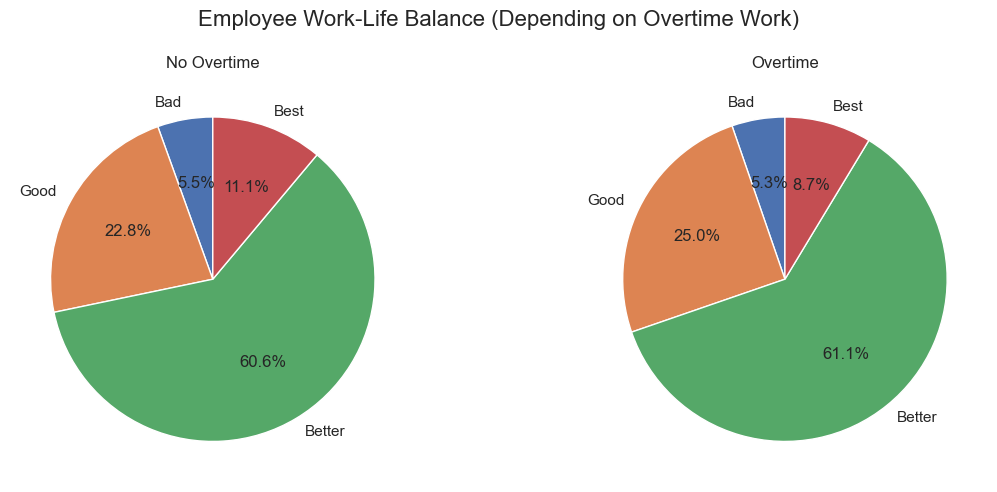

In [761]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches((12, 5))

plt.subplot(1, 2, 1)
plt.pie(
    balance_no_ovt["count"],  # albo inna kolumna
    labels=["Bad", "Good", "Better", "Best"],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("No Overtime")

plt.subplot(1, 2, 2)
plt.pie(
    balance_ovt["count"],  # albo inna kolumna
    labels=["Bad", "Good", "Better", "Best"],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Overtime")

plt.suptitle("Employee Work-Life Balance (Depending on Overtime Work)", fontsize=16)
plt.tight_layout()
plt.show()

### Education and Job Involvement Comparsion 

In [762]:
dict_education = {
    1: "1.Below College",
    2: "2.College",
    3: "3.Bachelor",
    4: "4.Master",
    5: "5.Doctor"
}

dict_involvment = {
    1: "1.Low",
    2: "2.Good",
    3: "3.Excellent",
    4: "4.Outstanding"
}

In [763]:
education = df[["Education", "JobInvolvement"]].copy()

# mapping the columns

education["Education"] = education["Education"].map(dict_education)

education["JobInvolvement"] = education["JobInvolvement"].map(dict_involvment)

# aggregation

education = education.groupby(["Education","JobInvolvement"]).size().reset_index(name="count")


In [764]:
# odering the data

education.sort_values(by=["Education", "JobInvolvement"], inplace=True)

education = education.rename(columns={"JobInvolvement": "Job Involvement Rating"})

education2 = education.copy()

# getting rid of numbers in the age group column

education["Education"] = education["Education"].str[2:]

education["Job Involvement Rating"] = education["Job Involvement Rating"].str[2:]


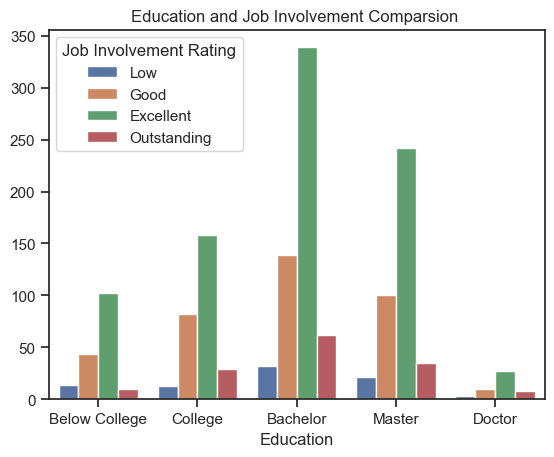

In [765]:
sns.barplot(
    data=education,
    x="Education",
    y="count",
    hue="Job Involvement Rating"
)

plt.title("Education and Job Involvement Comparsion ")
plt.ylabel("")
plt.xlabel("Education")

plt.show()


### Job Involvement by Education (Percentage Distribution) 

In [766]:
# creating and merging an additional dataframe

all_rows = education2.groupby("Education")["count"].sum()

education2 = education2.merge(all_rows, how="inner", on="Education")

In [767]:
# creating a new column

education2["Ratio"] = education2["count_x"] / education2["count_y"] * 100

education2["Ratio"] = education2["Ratio"].round(2)

In [768]:
# removing columns

education2.drop(labels=["count_x", "count_y"], axis=1, inplace=True)


In [769]:
# pivot table

education2 = education2.pivot(index="Education", columns="Job Involvement Rating", values="Ratio")

education2.reset_index(inplace=True)

In [770]:
# odering the data

education2.sort_values(by=["Education"], inplace=True)

In [771]:
# getting rid of numbers in the age group column

education2["Education"] = education2["Education"].str[2:]

education2.rename(columns={"1.Low" : "Low", "2.Good" : "Good", "3.Excellent" : "Excellent", "4.Outstanding" : "Outstanding"}, inplace=True)

education2.set_index(keys="Education", inplace=True)

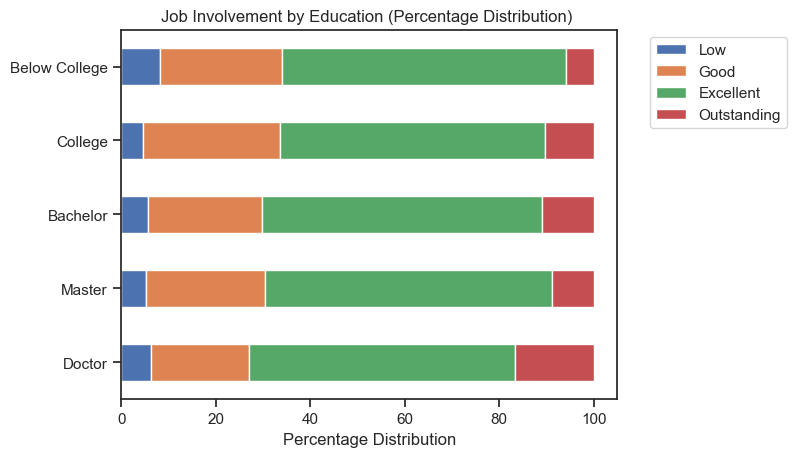

In [772]:
# chart

axis = education2.plot(kind="barh", stacked=True)

plt.title("Job Involvement by Education (Percentage Distribution) ")
plt.xlabel("Percentage Distribution")
plt.ylabel("")

axis.invert_yaxis()

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### Average Job Satisfaction Compared To Years Since The Last Promotion

In [773]:
promotion = df[["YearsSinceLastPromotion", "JobSatisfaction"]].copy()

promotion = promotion.groupby('YearsSinceLastPromotion')['JobSatisfaction'].mean().round(2)

In [774]:
chart_legend = """legenda
JobSatisfaction
1 = Low
2 = Medium
3 = High
4 = Very High
"""

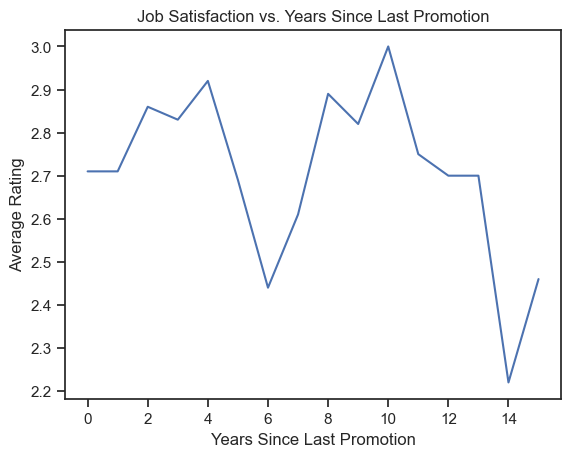

In [775]:
# chart 

sns.lineplot(
    data=promotion.reset_index(),
    x='YearsSinceLastPromotion',
    y="JobSatisfaction"
)

plt.title("Job Satisfaction vs. Years Since Last Promotion")
plt.ylabel("Average Rating")
plt.xlabel("Years Since Last Promotion")

plt.show()

### Employee Work-Life Balance 

In [776]:
balance = df["WorkLifeBalance"].value_counts()

all_values = len(df)

balance = balance.reset_index()

In [777]:
dict_rate = {
    1: '1.Bad',
    2: '2.Good',
    3: '3.Better',
    4: '4.Best'
}

balance["Rate"] = balance["WorkLifeBalance"].map(dict_rate)

balance.drop(columns="WorkLifeBalance", axis=1, inplace=True)

In [778]:
balance["count"] = balance["count"] / all_values * 100

balance["count"] = balance["count"].round(2)

balance.sort_values(by= "Rate", inplace=True)

balance["Rate"] = balance["Rate"].str[2:]

balance.set_index(keys="Rate", inplace=True)

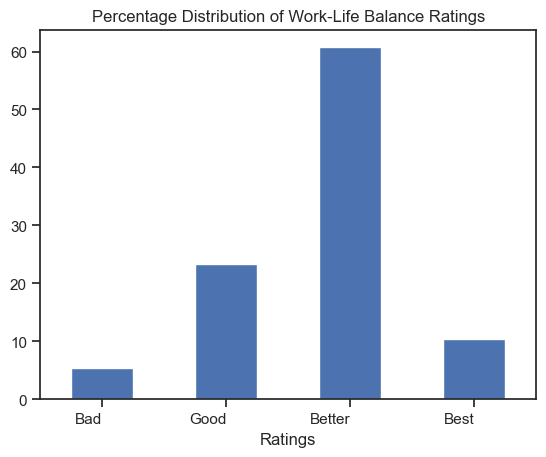

In [779]:
sns.set_theme(style='ticks')

balance.plot(kind="bar")

plt.title("Percentage Distribution of Work-Life Balance Ratings")
plt.ylabel("")
plt.xlabel("Ratings")

plt.legend().remove()

plt.xticks(rotation = 0, ha = "right")


plt.show()